# Recuperación de oro · Zyfra

**Objetivo.** Predecir el coeficiente de recuperación de oro a partir de los parámetros de extracción y purificación, para optimizar la producción y detectar parámetros no rentables.

**Dos objetivos.** `rougher.output.recovery` (recuperación tras la flotación) y `final.output.recovery` (recuperación final tras la purificación).

**Métrica.** sMAPE final = 25% · sMAPE(rougher) + 75% · sMAPE(final).

**Método.** Preparación y verificación de los datos → análisis del proceso de purificación → entrenamiento y comparación de modelos por validación cruzada → evaluación del mejor modelo sobre la muestra de prueba, recuperando la verdad desde el dataset fuente.

## Resumen ejecutivo

**Resultado.** El mejor modelo fue _[modelo]_, con un sMAPE final de _[X.XX %]_ sobre la muestra de prueba, por debajo del baseline constante (_[Y.YY %]_).

**Lectura de negocio.** _[Qué parámetros del proceso pesan más en la recuperación y dónde conviene intervenir para no operar parámetros no rentables.]_

**Cómo se llegó.** Se verificó el cálculo de la recuperación, se depuraron anomalías en train y test, y se compararon cinco modelos por validación cruzada con la métrica sMAPE 25/75 antes de la evaluación final.

## Contexto, condiciones y supuestos

**El proceso.** El mineral pasa por flotación (etapa *rougher*) y luego por dos etapas de purificación hasta el concentrado *final*. En cada etapa se miden concentraciones de metales (Au, Ag, Pb) y parámetros de operación.

**Los dos objetivos.** Se predice la recuperación en dos puntos del proceso: `rougher.output.recovery` y `final.output.recovery`.

**Condición del conjunto de prueba.** Las mediciones del proceso son de entrada (se toman cuando el mineral llega a la etapa) o de salida (se toman cuando la etapa ya terminó). Los dos objetivos son mediciones de salida: solo existen una vez que el proceso corrió. Como el test reproduce el momento real de la predicción —cuando el mineral va entrando y aún no hay resultados—, se le retiraron los objetivos y las columnas de salida; por eso el modelo se entrena solo con las características presentes en el test. La verdad para evaluarlo se recupera desde el dataset fuente (`full`), que sí la contiene, cruzando por `date`.

**Métrica.** sMAPE final = 25% · sMAPE(rougher) + 75% · sMAPE(final). El peso mayor recae en la recuperación final, que es la que define el rendimiento económico del proceso.

**Supuesto temporal.** Los datos se indexan por fecha y hora; parámetros cercanos en el tiempo tienden a parecerse. Esto justifica rellenar ausencias por arrastre del valor previo (`ffill`) tras ordenar cronológicamente.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import make_scorer
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 12345


### 1.1 Cargar y examinar los archivos

Se cargan los tres datasets: entrenamiento, prueba y fuente completa. Se revisan sus dimensiones para confirmar que el conjunto de prueba tiene menos columnas que el de entrenamiento.

In [16]:

train = pd.read_csv("../data/gold_recovery_train.csv")
test = pd.read_csv("../data/gold_recovery_test.csv")
full = pd.read_csv("../data/gold_recovery_full.csv")

print("train:", train.shape)
print("test: ", test.shape)
print("full: ", full.shape)

train: (16860, 87)
test:  (5856, 53)
full:  (22716, 87)


### 1.2 Verificar el cálculo de la recuperación

Se recalcula `rougher.output.recovery` con la fórmula de recuperación y se compara contra los valores del dataset mediante el EAM (error absoluto medio). Un EAM cercano a cero confirma que la columna está bien calculada.

**Resultado:** EAM = 9.2e-15, es decir, cero a efectos prácticos (solo ruido de redondeo). El cálculo es correcto.

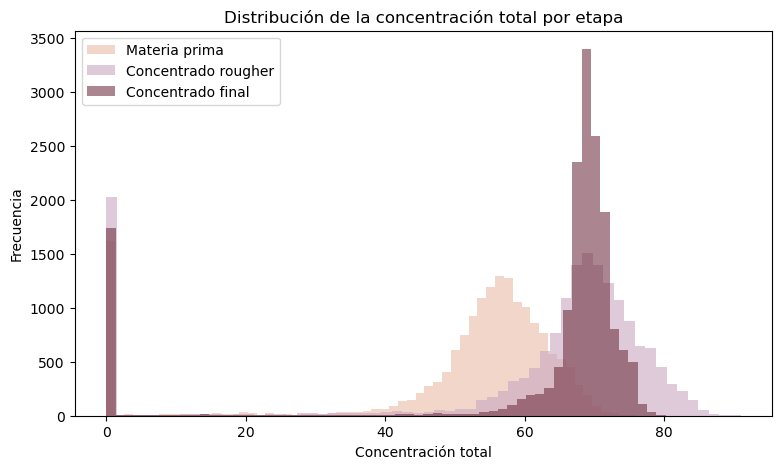

In [17]:
sustancias = ["au", "ag", "pb", "sol"]

etapas_totales = {
    "Materia prima": "rougher.input.feed_",
    "Concentrado rougher": "rougher.output.concentrate_",
    "Concentrado final": "final.output.concentrate_",
}

for nombre, prefijo in etapas_totales.items():
    cols = [prefijo + s for s in sustancias]
    train[nombre] = train[cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
for nombre, color in zip(etapas_totales, ["#EABCA5", "#C9A7BF", "#733445"]):
    ax.hist(train[nombre], bins=60, alpha=0.6, color=color, label=nombre)
ax.set_xlabel("Concentración total")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la concentración total por etapa")
ax.legend()
plt.show()

In [18]:

C = train["rougher.output.concentrate_au"]
F = train["rougher.input.feed_au"]
T = train["rougher.output.tail_au"]

recovery_calc = C * (F - T) / (F * (C - T)) * 100

real = train["rougher.output.recovery"]
mask = real.notna()
mae = (recovery_calc[mask] - real[mask]).abs().mean()

print("EAM entre cálculo y valor real:", mae)

EAM entre cálculo y valor real: 9.210911277458828e-15


### 1.3 Características ausentes en el conjunto de prueba

Se identifican las columnas presentes en entrenamiento pero ausentes en prueba, y se observa su tipo.

**Resultado:** 34 columnas ausentes, todas de tipo `.output.` (resultados del proceso) y `.calculation.` (cálculos derivados), incluidos los dos objetivos. No falta ninguna `.input.` ni `.state.`. La razón es que estos valores se miden *después* de terminar el proceso, por lo que no existen al momento de predecir; el modelo debe entrenarse usando solo las features disponibles en el conjunto de prueba.

In [3]:
faltantes = train.columns.difference(test.columns)

print("Columnas ausentes en test:", len(faltantes))
print()
for col in faltantes:
    print(col)

Columnas ausentes en test: 34

final.output.concentrate_ag
final.output.concentrate_au
final.output.concentrate_pb
final.output.concentrate_sol
final.output.recovery
final.output.tail_ag
final.output.tail_au
final.output.tail_pb
final.output.tail_sol
primary_cleaner.output.concentrate_ag
primary_cleaner.output.concentrate_au
primary_cleaner.output.concentrate_pb
primary_cleaner.output.concentrate_sol
primary_cleaner.output.tail_ag
primary_cleaner.output.tail_au
primary_cleaner.output.tail_pb
primary_cleaner.output.tail_sol
rougher.calculation.au_pb_ratio
rougher.calculation.floatbank10_sulfate_to_au_feed
rougher.calculation.floatbank11_sulfate_to_au_feed
rougher.calculation.sulfate_to_au_concentrate
rougher.output.concentrate_ag
rougher.output.concentrate_au
rougher.output.concentrate_pb
rougher.output.concentrate_sol
rougher.output.recovery
rougher.output.tail_ag
rougher.output.tail_au
rougher.output.tail_pb
rougher.output.tail_sol
secondary_cleaner.output.tail_ag
secondary_cleaner.ou

### 1.4 Preprocesamiento de datos

Se revisa la magnitud de valores ausentes y se ordena por fecha antes de tratarlos. Como los datos son una serie temporal indexada por `date` (parámetros cercanos en el tiempo son similares), los ausentes se rellenan con el valor más reciente disponible.

In [4]:
print("Ausentes en train:", train.isna().sum().sum())
print("Ausentes en test: ", test.isna().sum().sum())
print()
print("% de filas con algún ausente en train:", round(train.isna().any(axis=1).mean() * 100, 1))

Ausentes en train: 30320
Ausentes en test:  2360

% de filas con algún ausente en train: 34.7


Se convierte `date` a tipo fecha, se ordenan los tres datasets cronológicamente y se rellenan los ausentes con `ffill` (último valor conocido), coherente con la naturaleza temporal de los datos.

In [5]:
for df in [train, test, full]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

train.ffill(inplace=True)
test.ffill(inplace=True)
full.ffill(inplace=True)

print("Ausentes en train:", train.isna().sum().sum())
print("Ausentes en test: ", test.isna().sum().sum())


Ausentes en train: 0
Ausentes en test:  0


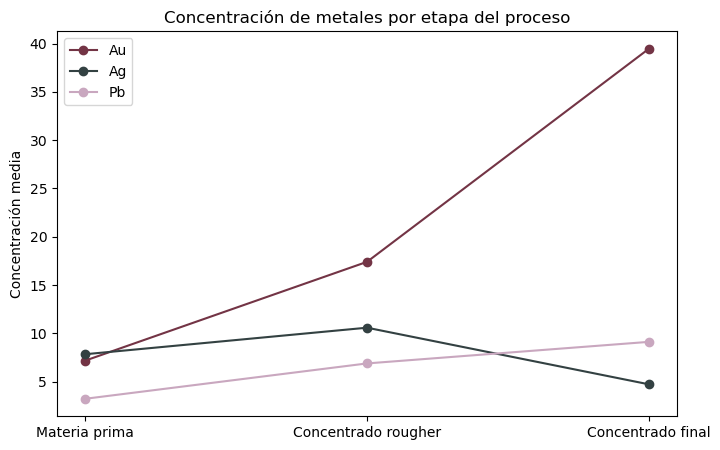

In [19]:

colores = {"Au": "#733445", "Ag": "#334142", "Pb": "#C9A7BF"}

etapas = {
    "Au": ["rougher.input.feed_au", "rougher.output.concentrate_au", "final.output.concentrate_au"],
    "Ag": ["rougher.input.feed_ag", "rougher.output.concentrate_ag", "final.output.concentrate_ag"],
    "Pb": ["rougher.input.feed_pb", "rougher.output.concentrate_pb", "final.output.concentrate_pb"],
}
nombres = ["Materia prima", "Concentrado rougher", "Concentrado final"]

fig, ax = plt.subplots(figsize=(8, 5))
for metal, cols in etapas.items():
    medias = [train[c].mean() for c in cols]
    ax.plot(nombres, medias, marker="o", color=colores[metal], label=metal)

ax.set_ylabel("Concentración media")
ax.set_title("Concentración de metales por etapa del proceso")
ax.legend()
plt.show()


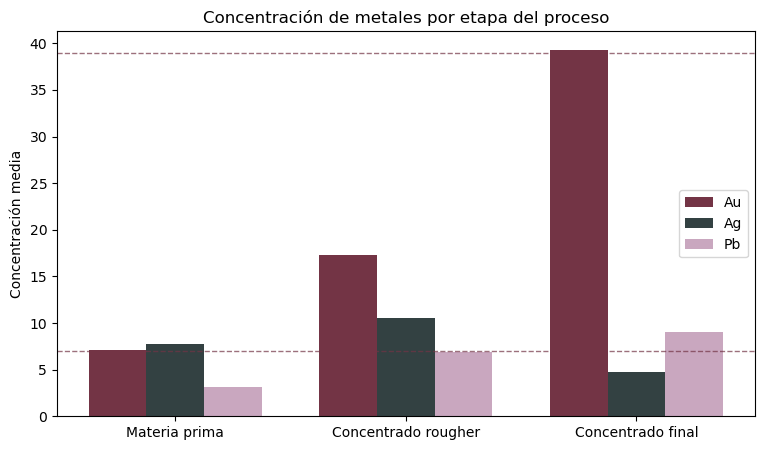

In [11]:
import numpy as np
import matplotlib.pyplot as plt

colores = {"Au": "#733445", "Ag": "#334142", "Pb": "#C9A7BF"}

etapas = {
    "Au": ["rougher.input.feed_au", "rougher.output.concentrate_au", "final.output.concentrate_au"],
    "Ag": ["rougher.input.feed_ag", "rougher.output.concentrate_ag", "final.output.concentrate_ag"],
    "Pb": ["rougher.input.feed_pb", "rougher.output.concentrate_pb", "final.output.concentrate_pb"],
}
nombres = ["Materia prima", "Concentrado rougher", "Concentrado final"]

x = np.arange(len(nombres))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metal, cols) in enumerate(etapas.items()):
    medias = [train[c].mean() for c in cols]
    ax.bar(x + (i - 1) * ancho, medias, ancho, color=colores[metal], label=metal)

ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylabel("Concentración media")
ax.set_title("Concentración de metales por etapa del proceso")
ax.legend()
ax.axhline(y=39, color="#733445", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y=7, color="#733445", linestyle="--", linewidth=1, alpha=0.7)
plt.show()

aqui se pide consejo al evaluador para elegir el mejor grafico, si bien me iria por los graficos de barra, al no tener nada de experiencia en el campo, me gustaria su feedback de cual seria la mejor opcion y si mi eleccion es correcta. 

**Hallazgo 2.1:** El oro (Au) se concentra fuertemente a lo largo del proceso —de ~7 en materia prima a ~39 en el concentrado final—, lo que confirma que el proceso cumple su objetivo. La plata (Ag) sube en la etapa rougher pero cae en la purificación final, comportamiento esperado: el proceso está optimizado para el oro, no para la plata. El plomo (Pb) se mantiene bajo y casi estable. En conjunto, el proceso enriquece oro y descarta los otros metales, justo como debe.


### 2.2 Distribución del tamaño de partícula: train vs test

Se comparan las distribuciones de `rougher.input.feed_size` (tamaño de partícula de la alimentación) en los conjuntos de entrenamiento y prueba. Si difieren significativamente, la evaluación del modelo no sería confiable.

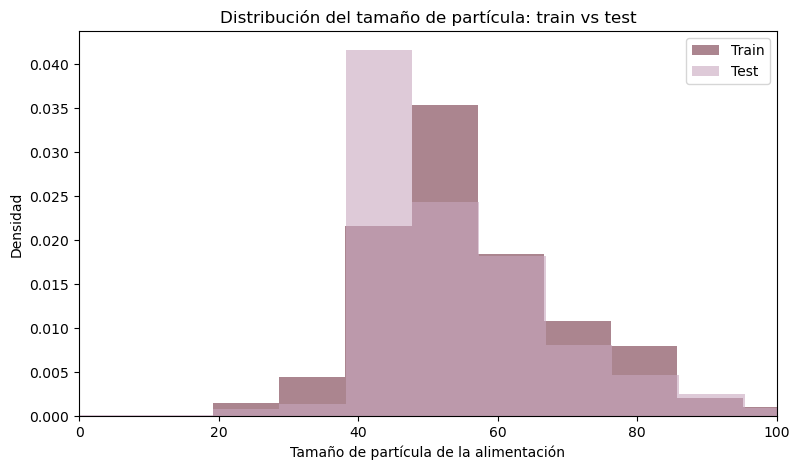

In [20]:


fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train["rougher.input.feed_size"], bins=50, alpha=0.6, color="#733445", label="Train", density=True)
ax.hist(test["rougher.input.feed_size"], bins=50, alpha=0.6, color="#C9A7BF", label="Test", density=True)

ax.set_xlabel("Tamaño de partícula de la alimentación")
ax.set_ylabel("Densidad")
ax.set_title("Distribución del tamaño de partícula: train vs test")
ax.legend()
ax.set_xlim(0, 100)
plt.show()

**Hallazgo 2.2:** Las distribuciones del tamaño de partícula en train y test se superponen casi por completo: mismo centro (~50) y misma forma. No hay diferencia significativa entre ambos conjuntos, por lo que la evaluación del modelo será confiable. Se observan algunos valores extremos aislados (>200) los trataremos mas adelante.

### 2.3 Concentraciones totales y eliminación de anomalías

Se suman todas las sustancias (Au, Ag, Pb, sólidos) en cada etapa. Las muestras cuya suma es cercana a cero son físicamente imposibles (errores de medición) y se eliminan del entrenamiento.

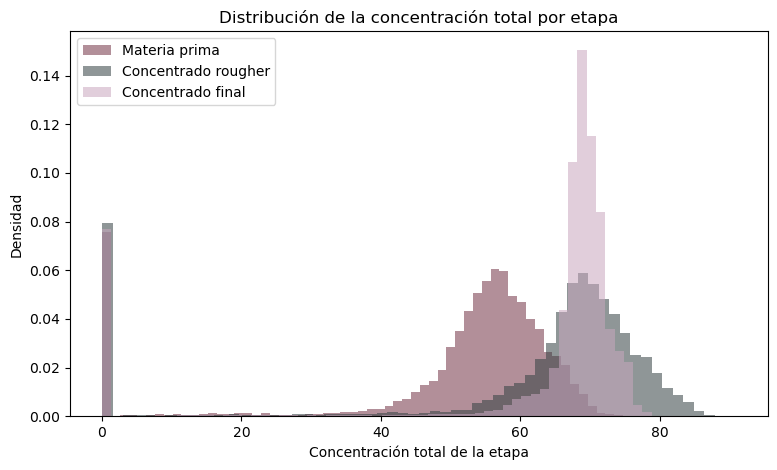

Materia prima
count    16860.000000
mean        50.176496
std         18.464659
min          0.000000
25%         50.180386
50%         55.756822
75%         60.258431
max         76.024095
dtype: float64
ceros: 1241

Concentrado rougher
count    16860.000000
mean        59.837827
std         24.166922
min          0.000000
25%         61.394517
50%         68.325658
75%         73.016415
max         90.964431
dtype: float64
ceros: 1575

Concentrado final
count    16860.000000
mean        61.191370
std         21.736070
min          0.000000
25%         66.511626
50%         68.800020
75%         70.693053
max         80.210644
dtype: float64
ceros: 1334



In [22]:
etapas_total = {
    "Materia prima": ["rougher.input.feed_au", "rougher.input.feed_ag", "rougher.input.feed_pb", "rougher.input.feed_sol"],
    "Concentrado rougher": ["rougher.output.concentrate_au", "rougher.output.concentrate_ag", "rougher.output.concentrate_pb", "rougher.output.concentrate_sol"],
    "Concentrado final": ["final.output.concentrate_au", "final.output.concentrate_ag", "final.output.concentrate_pb", "final.output.concentrate_sol"],
}

totales = {nombre: train[cols].sum(axis=1) for nombre, cols in etapas_total.items()}

colores = {"Materia prima": "#733445", "Concentrado rougher": "#334142", "Concentrado final": "#C9A7BF"}

fig, ax = plt.subplots(figsize=(9, 5))
for nombre, serie in totales.items():
    ax.hist(serie, bins=60, alpha=0.55, color=colores[nombre], label=nombre, density=True)

ax.set_xlabel("Concentración total de la etapa")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de la concentración total por etapa")
ax.legend()
plt.show()

for nombre, serie in totales.items():
    print(nombre)
    print(serie.describe())
    print("ceros:", (serie == 0).sum())
    print()

In [23]:
for nombre, serie in totales.items():
    bajos = serie[(serie > 0) & (serie < 10)]
    print(nombre, "→ valores entre 0 y 10:", len(bajos))
    print(serie[serie > 0].quantile([0.01, 0.02, 0.05]).round(2).to_dict())
    print()

Materia prima → valores entre 0 y 10: 453
{0.01: 0.04, 0.02: 0.04, 0.05: 32.57}

Concentrado rougher → valores entre 0 y 10: 502
{0.01: 0.04, 0.02: 0.04, 0.05: 35.17}

Concentrado final → valores entre 0 y 10: 431
{0.01: 0.04, 0.02: 0.04, 0.05: 53.91}



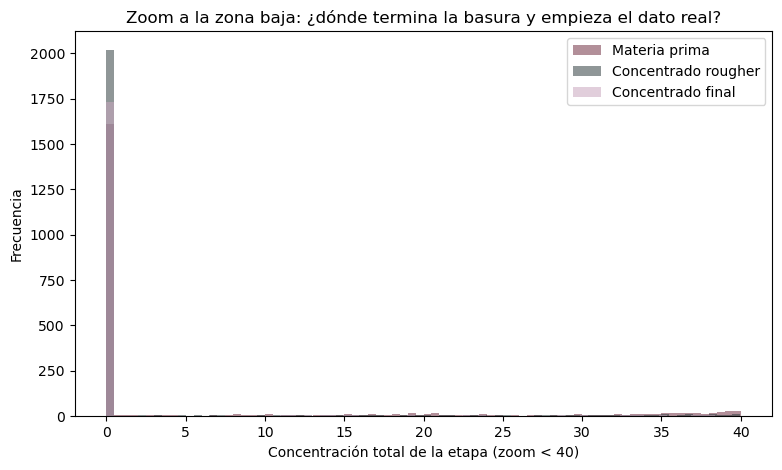

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, serie in totales.items():
    ax.hist(serie[serie < 40], bins=80, alpha=0.55, color=colores[nombre], label=nombre)

ax.set_xlabel("Concentración total de la etapa (zoom < 40)")
ax.set_ylabel("Frecuencia")
ax.set_title("Zoom a la zona baja: ¿dónde termina la basura y empieza el dato real?")
ax.legend()
plt.show()